# CS4305 Artificial Intelligence — Lab 10
## Knowledge Representation III: Semantic Networks, Frames and Scripts

**What you will learn today**
1. Build a **semantic network** and draw it
2. Answer questions using **inheritance** (and handle **exceptions**)
3. Represent objects with **frames**: slots, default values, procedures
4. Use a **script** to understand a short story

**How to use this notebook**
- 📊 **Visual explanation** cells already show a picture. Look at the picture first, then read the code.
- 💻 **Code** cells: click inside and press **Shift + Enter** to run them, from top to bottom.
- 📝 **Lab tasks** are at the end.

In [ ]:
#@title ⚙️ Diagram tools (only needed if you want to redraw the pictures)
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyBboxPatch, Rectangle

PURPLE, ORANGE, TEAL, ROSE, DARK = "#5B2A86", "#FF9F1C", "#1FA898", "#D1495B", "#1A1333"
LIGHT, GREY, WHITE = "#F3EEFA", "#A9A3B8", "#FFFFFF"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 12})

def tree_layout(children, root, gap=1.0):
    """Tidy layout for a tree given as {parent: [children]}."""
    pos, nxt = {}, [0.0]
    def walk(n, d):
        kids = children.get(n, [])
        if not kids:
            pos[n] = (nxt[0], -d); nxt[0] += gap
        else:
            for k in kids: walk(k, d + 1)
            xs = [pos[k][0] for k in kids]
            pos[n] = ((min(xs) + max(xs)) / 2, -d)
    walk(root, 0)
    return pos

def draw_graph(ax, pos, edges, directed=False, weights=None, colors=None, path=None, r=0.28,
               fs=13, label_below=False, badges=None, badge_color=ORANGE, edge_fs=11, names=None):
    """Draw nodes (circles) and edges. path = list of nodes to highlight in orange."""
    colors = colors or {}
    on_path = set()
    if path:
        for a, b in zip(path, path[1:]): on_path |= {(a, b), (b, a)}
    for i, (a, b) in enumerate(edges):
        (x1, y1), (x2, y2) = pos[a], pos[b]
        L = math.hypot(x2 - x1, y2 - y1); ux, uy = (x2 - x1) / L, (y2 - y1) / L
        s, e = (x1 + ux * r, y1 + uy * r), (x2 - ux * r, y2 - uy * r)
        hi = (a, b) in on_path
        ax.annotate("", xy=e, xytext=s, arrowprops=dict(arrowstyle="-|>" if directed else "-",
                    color=ORANGE if hi else GREY, lw=4 if hi else 1.8, shrinkA=0, shrinkB=0,
                    mutation_scale=18), zorder=1)
        if weights:
            w = weights[i]
            ax.text((x1 + x2) / 2, (y1 + y2) / 2, str(w), ha="center", va="center", fontsize=edge_fs,
                    color=DARK, fontweight="bold", zorder=4,
                    bbox=dict(boxstyle="round,pad=0.2", fc=WHITE, ec="none"))
    for n, (x, y) in pos.items():
        c = colors.get(n, PURPLE)
        ax.add_patch(Circle((x, y), r, fc=c, ec=WHITE, lw=2, zorder=3))
        text = (names or {}).get(n, n)
        if label_below:
            ax.text(x, y - r - 0.06, text, ha="center", va="top", fontsize=fs, color=DARK, fontweight="bold", zorder=5)
        else:
            ax.text(x, y, text, ha="center", va="center", fontsize=fs, color=WHITE if c not in (ORANGE, LIGHT, WHITE) else DARK,
                    fontweight="bold", zorder=5)
    if badges:
        for n, t in badges.items():
            x, y = pos[n]
            ax.add_patch(Circle((x + r * 0.95, y + r * 0.95), r * 0.55, fc=badge_color, ec=WHITE, lw=1.5, zorder=6))
            ax.text(x + r * 0.95, y + r * 0.95, str(t), ha="center", va="center", fontsize=fs - 3,
                    color=DARK, fontweight="bold", zorder=7)
    xs = [p[0] for p in pos.values()]; ys = [p[1] for p in pos.values()]
    m = r * 2.2
    ax.set_xlim(min(xs) - m, max(xs) + m); ax.set_ylim(min(ys) - m - (0.35 if label_below else 0), max(ys) + m)
    ax.set_aspect("equal"); ax.axis("off")

def box(ax, x, y, w, h, text, fc=PURPLE, tc=WHITE, fs=13, bold=True, ec=None, round_=True):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.08" if round_ else "square,pad=0",
                                fc=fc, ec=ec or fc, lw=1.5, zorder=2))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fs, color=tc,
            fontweight="bold" if bold else "normal", zorder=3)

def arrow(ax, x1, y1, x2, y2, color=DARK, lw=2, text=None, fs=11):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, shrinkA=0, shrinkB=0, mutation_scale=16))
    if text:
        ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.12, text, ha="center", va="bottom", fontsize=fs, color=DARK)

def board(ax, x0, y0, state, size=0.9, title=None, highlight=None, fc=LIGHT):
    """Draw an 8-puzzle board. state = string like '123456780' (0 = blank)."""
    highlight = highlight or {}
    for i, ch in enumerate(state):
        r, c = divmod(i, 3)
        x, y = x0 + c * size, y0 - r * size
        blank = ch == "0"
        ax.add_patch(Rectangle((x, y), size, size, fc=WHITE if blank else highlight.get(ch, fc),
                               ec=DARK, lw=2, zorder=2))
        if not blank:
            ax.text(x + size / 2, y + size / 2, ch, ha="center", va="center", fontsize=20, fontweight="bold",
                    color=WHITE if highlight.get(ch) in (PURPLE, ROSE, TEAL) else DARK, zorder=3)
    if title:
        ax.text(x0 + 1.5 * size, y0 + size + 0.25, title, ha="center", va="bottom", fontsize=14, fontweight="bold", color=DARK)

def finish(fig, title=None):
    if title:
        fig.suptitle(title, fontsize=16, fontweight="bold", color=DARK)
    fig.tight_layout()


# ---- shared data for this lab's diagrams ----
def _text_tree(ax, children, root, labels, colors=None, gap=1.6, w=1.35, h=0.5, fs=12, level_gap=1.1):
    """Draw a tree whose nodes are text boxes. labels: node-id -> text."""
    colors = colors or {}
    pos = tree_layout(children, root, gap=gap)
    pos = {k: (x, y * level_gap) for k, (x, y) in pos.items()}
    for p, ks in children.items():
        for k in ks:
            (x1, y1), (x2, y2) = pos[p], pos[k]
            ax.plot([x1, x2], [y1 - h / 2, y2 + h / 2], color=GREY, lw=1.8, zorder=1)
    for k, (x, y) in pos.items():
        fc = colors.get(k, PURPLE)
        box(ax, x - w / 2, y - h / 2, w, h, labels.get(k, k), fc=fc, tc=DARK if fc in (ORANGE, LIGHT, WHITE) else WHITE, fs=fs)
    xs = [p[0] for p in pos.values()]; ys = [p[1] for p in pos.values()]
    ax.set_xlim(min(xs) - w, max(xs) + w); ax.set_ylim(min(ys) - h * 1.5, max(ys) + h * 1.5)
    ax.set_aspect("equal"); ax.axis("off")
    return pos

ZOO = [("R1", ["has_hair"], "mammal"), ("R2", ["gives_milk"], "mammal"), ("R3", ["has_feathers"], "bird"),
       ("R4", ["mammal", "eats_meat"], "carnivore"), ("R5", ["carnivore", "tawny", "dark_spots"], "cheetah"),
       ("R6", ["carnivore", "tawny", "black_stripes"], "tiger"), ("R7", ["bird", "swims", "cannot_fly"], "penguin")]

NET_POS = {"Animal": (3.5, 4), "Bird": (1.5, 2.4), "Mammal": (5.5, 2.4), "Canary": (0.3, 0.8), "Penguin": (2.7, 0.8),
           "Cow": (5.5, 0.8), "Tweety": (0.3, -0.8), "fly": (-1.2, 2.4), "feathers": (0.4, 3.7), "breathe": (6.9, 4.4),
           "milk": (7.4, 0.8), "yellow": (-1.4, 0.2)}

NET_EDGES = [("Bird", "Animal", "is-a"), ("Mammal", "Animal", "is-a"), ("Canary", "Bird", "is-a"), ("Penguin", "Bird", "is-a"),
             ("Cow", "Mammal", "is-a"), ("Tweety", "Canary", "instance"), ("Bird", "fly", "can"), ("Bird", "feathers", "has"),
             ("Animal", "breathe", "can"), ("Cow", "milk", "gives"), ("Canary", "yellow", "colour")]

def _net(ax, path=None, exception=True):
    concept = {"Animal", "Bird", "Mammal", "Canary", "Penguin", "Cow", "Tweety"}
    on = set(zip(path, path[1:])) if path else set()
    for a, b, lab in NET_EDGES:
        (x1, y1), (x2, y2) = NET_POS[a], NET_POS[b]
        hi = (a, b) in on
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle="-|>", lw=4 if hi else 1.8,
                    color=ORANGE if hi else GREY, shrinkA=22, shrinkB=22, mutation_scale=16))
        ax.text((x1 + x2) / 2, (y1 + y2) / 2, lab, fontsize=10.5, ha="center", va="center", color=DARK,
                bbox=dict(boxstyle="round,pad=0.15", fc=WHITE, ec="none"))
    if exception:
        (x1, y1), (x2, y2) = NET_POS["Penguin"], NET_POS["fly"]
        ax.annotate("", xy=(x2 + 0.3, y2 - 0.2), xytext=(x1 - 0.3, y1 + 0.1), arrowprops=dict(arrowstyle="-|>", lw=2, color=ROSE, ls="--",
                    connectionstyle="arc3,rad=-0.25", shrinkA=14, shrinkB=14))
        ax.text(0.2, 1.55, "can: NO", fontsize=10.5, color=ROSE, fontweight="bold")
    for n_, (x, y) in NET_POS.items():
        if n_ in concept:
            c = ORANGE if n_ == "Tweety" else PURPLE
            box(ax, x - 0.62, y - 0.28, 1.24, 0.56, n_, fc=c, tc=DARK if c == ORANGE else WHITE, fs=11.5)
        else:
            box(ax, x - 0.55, y - 0.25, 1.1, 0.5, n_, fc=LIGHT, tc=DARK, fs=11, bold=False)
    ax.set_xlim(-2.1, 8.1); ax.set_ylim(-1.3, 4.9); ax.set_aspect("equal"); ax.axis("off")
print('Diagram tools ready')

---
## Part 1: Semantic networks
A semantic network is a **graph of knowledge**: nodes are concepts (Bird, Animal) and labelled arrows are relations (*is-a*, *has*, *can*).

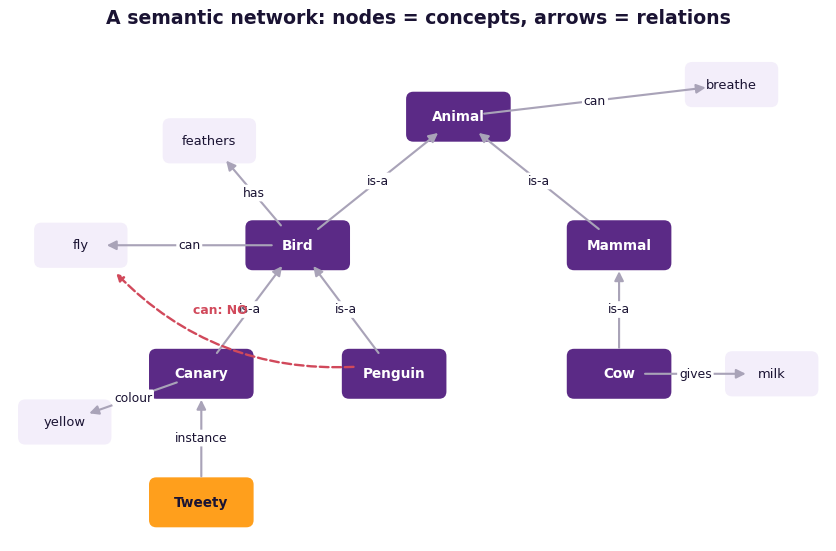

In [ ]:
#@title 📊 Visual explanation: a small semantic network
def fig_semantic_net():
    fig, ax = plt.subplots(figsize=(11, 6.6)); _net(ax)
    finish(fig, "A semantic network: nodes = concepts, arrows = relations")
    return fig

fig_semantic_net()
plt.show()

In [ ]:
# ===== A semantic network is a graph: nodes = concepts, labelled arrows = relations =====
import networkx as nx
net = nx.DiGraph()
links = [
    ("Bird", "is-a", "Animal"), ("Mammal", "is-a", "Animal"),
    ("Canary", "is-a", "Bird"), ("Penguin", "is-a", "Bird"), ("Cow", "is-a", "Mammal"),
    ("Tweety", "instance", "Canary"),
    ("Animal", "can", "breathe"), ("Animal", "has", "skin"),
    ("Bird", "can", "fly"), ("Bird", "has", "feathers"),
    ("Canary", "colour", "yellow"), ("Canary", "can", "sing"),
    ("Cow", "gives", "milk"), ("Mammal", "has", "fur"),
]
for a, rel, b in links:
    net.add_edge(a, b, relation=rel)
exceptions = {("Penguin", "can"): ["NOT fly", "swim"]}   # penguins are special birds
print("Nodes:", list(net.nodes))
print("Number of links:", net.number_of_edges())

In [ ]:
import matplotlib.pyplot as plt
pos = {"Animal": (3.5, 4), "Bird": (1.5, 2.4), "Mammal": (5.5, 2.4), "Canary": (0.3, 0.8), "Penguin": (2.7, 0.8),
       "Cow": (5.5, 0.8), "Tweety": (0.3, -0.8), "fly": (-1.2, 2.4), "feathers": (0.4, 3.7), "breathe": (6.9, 4.4),
       "skin": (2.0, 5.0), "milk": (7.4, 0.8), "yellow": (-1.4, 0.2), "sing": (-1.2, -0.6), "fur": (7.2, 2.9)}
plt.figure(figsize=(11, 7))
concepts = ["Animal", "Bird", "Mammal", "Canary", "Penguin", "Cow", "Tweety"]
nx.draw_networkx_nodes(net, pos, nodelist=concepts, node_color="#5B2A86", node_size=2200)
nx.draw_networkx_nodes(net, pos, nodelist=[n for n in net if n not in concepts], node_color="#F3EEFA", node_size=1500)
nx.draw_networkx_labels(net, pos, labels={n: n for n in concepts}, font_color="white", font_weight="bold")
nx.draw_networkx_labels(net, pos, labels={n: n for n in net if n not in concepts})
nx.draw_networkx_edges(net, pos, arrows=True, arrowsize=18, edge_color="grey", node_size=2200)
nx.draw_networkx_edge_labels(net, pos, edge_labels=nx.get_edge_attributes(net, "relation"), font_size=9)
plt.axis("off"); plt.show()

---
## Part 2: Inheritance
We never wrote *"Tweety can fly"*. The computer finds it by climbing the **is-a** links: Tweety → Canary → Bird → *can fly*. An **exception** on Penguin blocks the inherited *fly*.

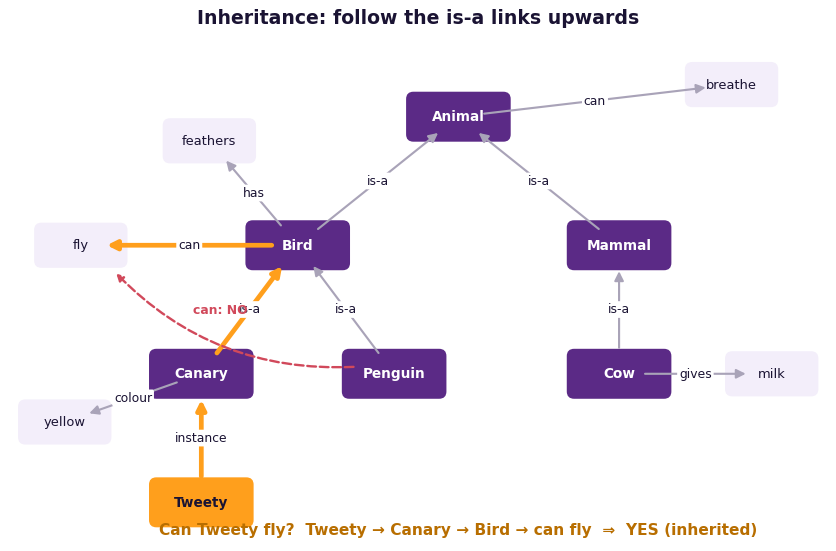

In [ ]:
#@title 📊 Visual explanation: following the links upwards
def fig_inheritance():
    fig, ax = plt.subplots(figsize=(11, 6.6)); _net(ax, path=["Tweety", "Canary", "Bird", "fly"])
    ax.text(3.5, -1.2, "Can Tweety fly?  Tweety → Canary → Bird → can fly  ⇒  YES (inherited)", ha="center", fontsize=13,
            fontweight="bold", color="#B86E00")
    finish(fig, "Inheritance: follow the is-a links upwards")
    return fig

fig_inheritance()
plt.show()

In [ ]:
# ===== Answer questions by following links (with inheritance) =====
def parents(node):
    return [b for b in net.successors(node) if net[node][b]["relation"] in ("is-a", "instance")]

def ask(node, relation):
    """Collect answers from this node AND every node above it (inheritance).
    Exceptions on a lower node block what is inherited from higher nodes."""
    answers, blocked, current = [], set(), [node]
    while current:
        nxt = []
        for n in current:
            for value in exceptions.get((n, relation), []):
                if value.startswith("NOT "):
                    blocked.add(value[4:]); answers.append((value, n))
                else:
                    answers.append((value, n))
            for b in net.successors(n):
                if net[n][b]["relation"] == relation and b not in blocked:
                    answers.append((b, n))
            nxt += parents(n)
        current = nxt
    return answers

for node, rel in [("Tweety", "can"), ("Tweety", "has"), ("Penguin", "can"), ("Cow", "has"), ("Cow", "gives")]:
    found = ", ".join(f"{v} (from {src})" for v, src in ask(node, rel))
    print(f"{node} {rel}:  {found}")

In [ ]:
# ===== "Is X a kind of Y?" — follow is-a links all the way up =====
def is_a(x, y):
    return x == y or any(is_a(p, y) for p in parents(x))

for x, y in [("Tweety", "Animal"), ("Penguin", "Bird"), ("Cow", "Bird"), ("Tweety", "Mammal")]:
    print(f"Is {x} a kind of {y}?  {is_a(x, y)}")

---
## Part 3: Frames
A frame is like a **form** for one kind of object. It has **slots** (fields) with **fillers** (values).
- **Default value**: used unless we say otherwise (program = BS CS)
- **Inherited value**: taken from the parent frame
- **If-needed procedure**: a small program that computes the value only when asked (age from birth year)

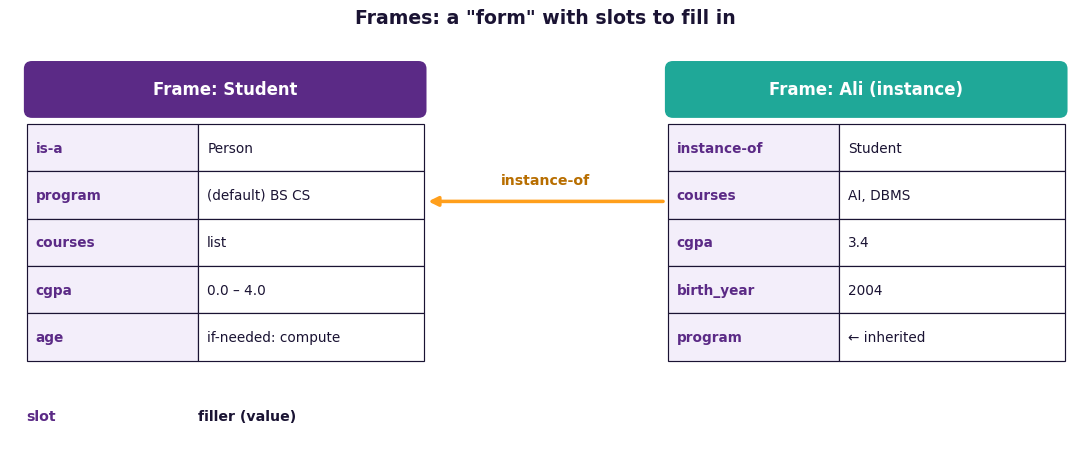

In [ ]:
#@title 📊 Visual explanation: a Student frame and an instance frame
def fig_frame():
    fig, ax = plt.subplots(figsize=(13, 5.4))
    def frame(x, title, slots, fc):
        box(ax, x, 4.1, 4.4, 0.6, title, fc=fc, fs=14)
        for i, (s, v) in enumerate(slots):
            y = 3.45 - i * 0.55
            ax.add_patch(Rectangle((x, y), 1.9, 0.55, fc=LIGHT, ec=DARK, lw=1)); ax.add_patch(Rectangle((x + 1.9, y), 2.5, 0.55, fc=WHITE, ec=DARK, lw=1))
            ax.text(x + 0.1, y + 0.27, s, va="center", fontsize=11.5, fontweight="bold", color=PURPLE)
            ax.text(x + 2.0, y + 0.27, v, va="center", fontsize=11.5, color=DARK)
    frame(0.2, "Frame: Student", [("is-a", "Person"), ("program", "(default) BS CS"), ("courses", "list"), ("cgpa", "0.0 – 4.0"), ("age", "if-needed: compute")], PURPLE)
    frame(7.3, "Frame: Ali (instance)", [("instance-of", "Student"), ("courses", "AI, DBMS"), ("cgpa", "3.4"), ("birth_year", "2004"), ("program", "← inherited")], TEAL)
    arrow(ax, 7.25, 3.1, 4.65, 3.1, color=ORANGE, lw=3); ax.text(5.95, 3.3, "instance-of", ha="center", fontsize=12, color="#B86E00", fontweight="bold")
    ax.text(0.2, 0.55, "slot", fontsize=12, color=PURPLE, fontweight="bold"); ax.text(2.1, 0.55, "filler (value)", fontsize=12, color=DARK, fontweight="bold")
    ax.set_xlim(0, 11.9); ax.set_ylim(0.3, 4.9); ax.axis("off")
    finish(fig, "Frames: a \"form\" with slots to fill in")
    return fig

fig_frame()
plt.show()

In [ ]:
# ===== Frames: objects with slots, default values and procedures =====
class Frame:
    def __init__(self, name, parent=None, **slots):
        self.name, self.parent, self.slots = name, parent, slots

    def get(self, slot, owner=None):
        owner = owner or self                                      # the frame that asked
        if slot in self.slots:
            value = self.slots[slot]
            return value(owner) if callable(value) else value     # "if-needed" procedure
        if self.parent:
            return self.parent.get(slot, owner)                    # inherit from the parent frame
        return None

    def show(self):
        print(f"--- Frame: {self.name} ---")
        keys = set(self.slots)
        f = self.parent
        while f:
            keys |= set(f.slots); f = f.parent
        for k in sorted(keys):
            source = "own" if k in self.slots else "inherited"
            print(f"  {k:12s}: {str(self.get(k)):22s} ({source})")

person  = Frame("Person", legs=2, can="talk", nationality="Pakistani")
student = Frame("Student", parent=person, program="BS CS", cgpa=0.0,
                age=lambda f: 2026 - f.get("birth_year"))           # computed only when asked
ali  = Frame("Ali", parent=student, birth_year=2004, cgpa=3.4, courses=["AI", "DBMS"])
sara = Frame("Sara", parent=student, birth_year=2005, cgpa=3.9, program="BS AI")
ali.show(); sara.show()

### Frames and object-oriented programming
Frames came first (Minsky, 1974). Classes in Python and Java use the same ideas: attributes, inheritance and default values.

In [ ]:
# ===== Frames are the ancestors of classes in object-oriented programming =====
class Person:
    legs = 2
    nationality = "Pakistani"

class Student(Person):
    program = "BS CS"                        # default value
    def __init__(self, name, birth_year, cgpa):
        self.name, self.birth_year, self.cgpa = name, birth_year, cgpa
    @property
    def age(self):                           # like an "if-needed" slot
        return 2026 - self.birth_year

usman = Student("Usman", 2003, 3.1)
print(usman.name, "| legs:", usman.legs, "| program:", usman.program, "| age:", usman.age)

---
## Part 4: Scripts
A script describes the **usual sequence of events** in a familiar situation. When a story leaves things out, the script lets us **fill in the gaps** — just like people do.

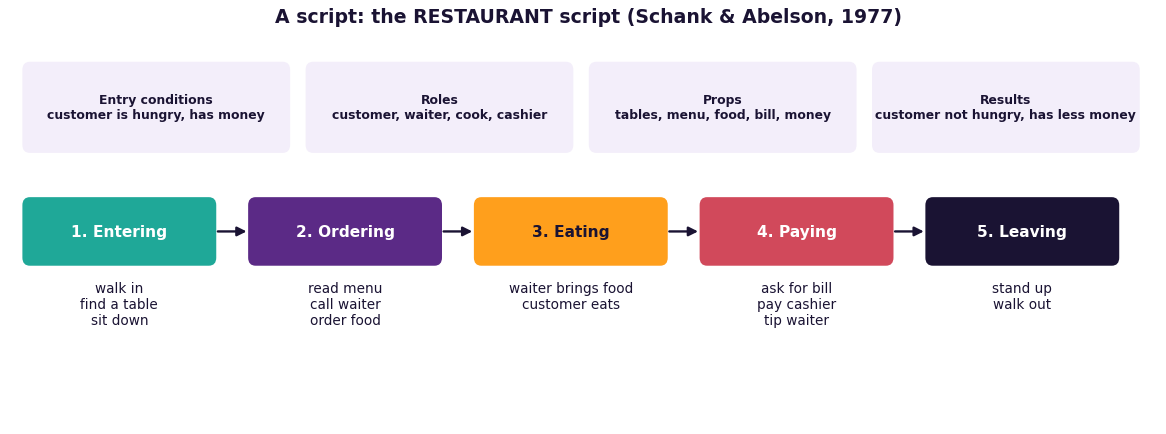

In [ ]:
#@title 📊 Visual explanation: the restaurant script
def fig_script():
    fig, ax = plt.subplots(figsize=(14, 5.2))
    scenes = [("1. Entering", "walk in\nfind a table\nsit down", TEAL), ("2. Ordering", "read menu\ncall waiter\norder food", PURPLE),
              ("3. Eating", "waiter brings food\ncustomer eats", ORANGE), ("4. Paying", "ask for bill\npay cashier\ntip waiter", ROSE),
              ("5. Leaving", "stand up\nwalk out", DARK)]
    for i, (t, d, c) in enumerate(scenes):
        x = 0.2 + i * 2.75
        box(ax, x, 2.3, 2.3, 0.7, t, fc=c, tc=DARK if c == ORANGE else WHITE, fs=13)
        ax.text(x + 1.15, 2.1, d, ha="center", va="top", fontsize=11.5, color=DARK)
        if i < 4: arrow(ax, x + 2.35, 2.65, x + 2.7, 2.65)
    info = [("Entry conditions", "customer is hungry, has money"), ("Roles", "customer, waiter, cook, cashier"),
            ("Props", "tables, menu, food, bill, money"), ("Results", "customer not hungry, has less money")]
    for i, (k, v) in enumerate(info):
        x = 0.2 + i * 3.45
        box(ax, x, 3.55, 3.2, 0.95, f"{k}\n{v}", fc=LIGHT, tc=DARK, fs=10.5)
    ax.set_xlim(0, 14); ax.set_ylim(0.5, 4.7); ax.axis("off")
    finish(fig, "A script: the RESTAURANT script (Schank & Abelson, 1977)")
    return fig

fig_script()
plt.show()

In [ ]:
# ===== Scripts: the usual sequence of events in a familiar situation =====
restaurant_script = {
    "name": "Restaurant",
    "entry_conditions": ["customer is hungry", "customer has money"],
    "roles": ["customer", "waiter", "cook", "cashier"],
    "props": ["table", "menu", "food", "bill", "money"],
    "scenes": {
        "Entering": ["customer enters", "customer sits at a table"],
        "Ordering": ["customer reads the menu", "customer orders food"],
        "Eating":   ["waiter brings food", "customer eats food"],
        "Paying":   ["customer asks for the bill", "customer pays the cashier"],
        "Leaving":  ["customer leaves the restaurant"],
    },
    "results": ["customer is not hungry", "customer has less money", "restaurant has more money"],
}

def understand(story, script, customer):
    """Match a short story to the script and fill in everything that was NOT said."""
    print("Story:", " ".join(story), "\n")
    print("What a person understands (✓ = said in the story, · = filled in by the script):")
    for scene, events in script["scenes"].items():
        for e in events:
            mark = "✓" if any(key in e for key in story_keys(story)) else "·"
            print(f"  {mark} [{scene:8s}] {e.replace('customer', customer)}")
    print("\nResults:", [r.replace("customer", customer) for r in script["results"]])

def story_keys(story):
    keys = []
    for s in story:
        s = s.lower()
        if "went" in s or "enter" in s: keys.append("enters")
        if "order" in s: keys.append("orders")
        if "ate" in s or "eat" in s: keys.append("eats")
        if "left" in s or "leave" in s: keys.append("leaves")
    return keys

understand(["Ali went to a restaurant.", "He ordered biryani.", "He left happily."], restaurant_script, "Ali")

In [ ]:
# ===== The script answers questions the story never mentioned =====
def answer(question):
    q = question.lower()
    if "pay" in q:    return "Probably yes — the Paying scene comes before Leaving in the script."
    if "eat" in q:    return "Probably yes — people order food in order to eat it."
    if "sit" in q:    return "Probably yes — the Entering scene includes sitting at a table."
    if "hungry" in q: return "Before: yes (entry condition). After: no (result)."
    return "The script does not say."

for q in ["Did Ali pay?", "Did Ali eat the biryani?", "Was Ali hungry?", "What colour was the table?"]:
    print(f"Q: {q:28s} A: {answer(q)}")

---
## 📝 Lab Tasks
1. Add **Fish** (is-a Animal, can swim, has fins) and **Shark** (is-a Fish) to the network. Ask: *what can a Shark do?*
2. Add an exception: an **Ostrich** is a Bird that cannot fly but can run fast.
3. Create a **Teacher** frame (is-a Person) with slots: department, courses, salary (default 100000). Make a frame for your AI teacher.
4. Write an **"exam hall" script**: entry conditions, roles, props, scenes and results. Use it to answer: *"Ahmed entered the hall and later left happily. Did he write the paper?"*
5. **Think:** what is one advantage and one disadvantage of semantic networks compared with logic?